<a href="https://colab.research.google.com/github/sanjuchatrathi-star/ML/blob/main/Experiment_4_Postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame

# Features and Target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nFirst Five Rows")
print(df.head())

Dataset Shape: (20640, 9)

Missing Values:

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

First Five Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [4]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_predictions = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Performance
MAE : 0.5332001304956565
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


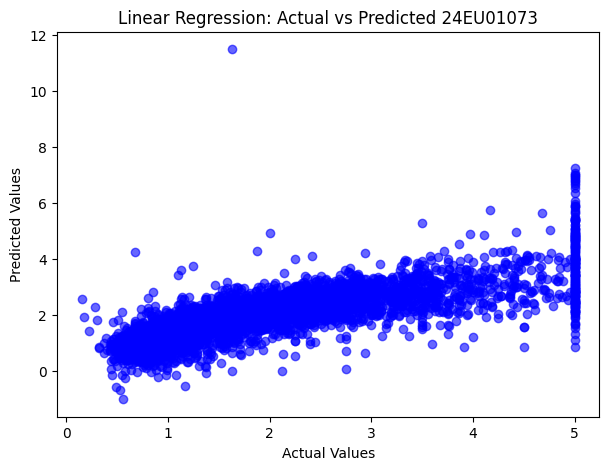

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, lr_predictions, color="blue", alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted 24EU01073")

plt.show()

In [7]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

svr_predictions = svr_model.predict(X_test_scaled)

In [8]:
mae = mean_absolute_error(y_test, svr_predictions)
mse = mean_squared_error(y_test, svr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Support Vector Regression
MAE : 0.39859907695205365
MSE : 0.357004031933865
RMSE: 0.5974981438748282
R2 Score: 0.7275628923016773


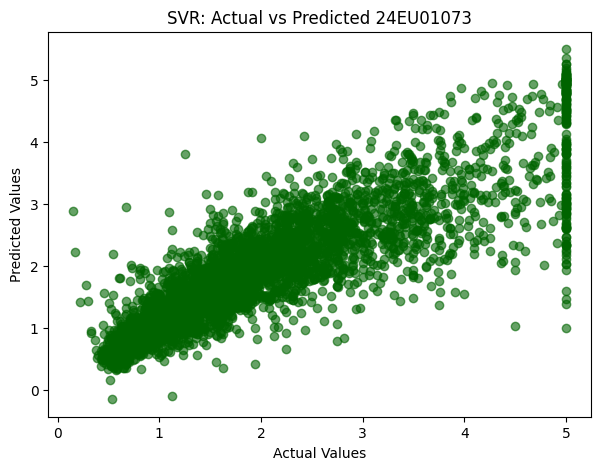

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, svr_predictions,
            color="darkgreen",
            alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted 24EU01073")

plt.show()

In [10]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, dt_predictions)
mse = mean_squared_error(y_test, dt_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Decision Tree Regression
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


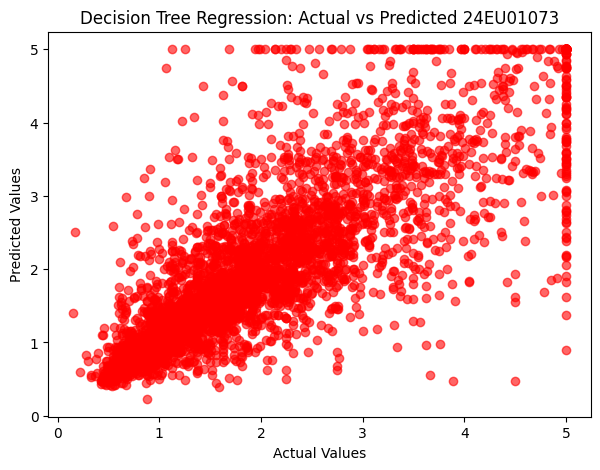

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,
            dt_predictions,
            color="red",
            alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Regression: Actual vs Predicted 24EU01073")

plt.show()

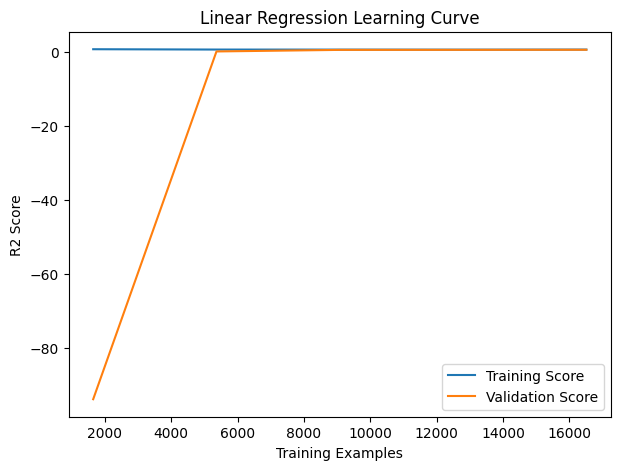

In [ ]:
from sklearn.model_selection import learning_curve

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

for name, model in models.items():

    if name == "Decision Tree":
        X_used = X
    else:
        X_used = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_used,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1,1.0,5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(7,5))

    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, test_mean, label="Validation Score")

    plt.title(name + " Learning Curve 24EU01073")
    plt.xlabel("Training Examples")
    plt.ylabel("R2 Score")
    plt.legend()

    plt.show()

In [ ]:
results = pd.DataFrame({
    "Model":["Linear Regression","Support Vector Regression","Decision Tree Regression"],
    "MAE":[
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, svr_predictions),
        mean_absolute_error(y_test, dt_predictions)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, svr_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions))
    ],
    "R2 Score":[
        r2_score(y_test, lr_predictions),
        r2_score(y_test, svr_predictions),
        r2_score(y_test, dt_predictions)
    ]
})

print(results)